# Web Scraping

Lots of great data is available online, but available through inconveniently formatted web pages. When this is the case, sometimes you can simply copy and paste the data into a .csv file and go on with your life. But if there are many records to parse and combine into a dataset, that might be impossible. Can we automate the collection of data from online sources?

This is called web scraping. Broadly speaking: Web scraping is legal, but what you plan to do with the results of your scraping might not be. In general, most sites do not want you to scrape them at this point, but there is not really a way to stop you if you are sufficiently motivated. Be careful to use server resources respectfully (not too many requests per unit time), think seriously about privacy concerns, and be careful who you share your work with and how it is used.

We'll be scraping data about used cars in Charlottesville from Craigslist, particularly this page: https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0 

We'll use the `requests` package to get web pages off the Internet and into Python. Again, we'll use a header with a user-agent that masks our true identity so that we're not rejected by the server. This particular url points to the car listings for Craigslist in Charlottesville. To use requests, you pass a `url` for the page you want and a `header` that controls how you appear to the server to `requests.get`:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0' # The page we want to scrape
raw = requests.get(url,headers=header) # Get page


<Response [200]>


Now that we have that particular page available locally, we want to **parse** it and get results from it. To do that, we can use a package called `beautifulSoup` or `bs4`.

What does `beautifulSoup` do for us? Let's go to the web page of interest. You probably see something like this:

![Listings](./src/craigslist.png "Craigslist")

But if you "view page source" -- which is CTRL+U -- in Chrome, you see what the computer sees:

![Listings](./src/craigslist_source.png "Craigslist")

Since your web browser needs lots of instructions about how to render the text, pictures, and other content on your web page, there are a lot of clues about where the data live and how to extricate them from a page. These clues are called **tags**. If you wander the source for the search page on cars, you see a particular `class = "cl-static-search-result"` term appear attached to each listing:

![Listings](./src/listing.png "Craigslist")

This structure can be exploited to search the page for information. This kind of detective work -- looking at the page source, finding the interesting tags, and then searching the page with `beautifulSoup` -- is the basic job of web scraping.

What I do is look at the rendered page, find the text I want and copy it, then search for that text in the HTML code that the computer sees. When I find the text I want, I look for the tag nearby. Here, it's `cl-static-search-result`: That's what I'll want beautifulSoup to search for.

The following code chunk takes the raw content from `requests` and turns it into a beautifulSoup object, which can search the page and return results for us:

In [ ]:
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

[<li class="cl-static-search-result" title="2013 Ford Fusion SE">
<a href="https://charlottesville.craigslist.org/cto/d/charlottesville-2013-ford-fusion-se/7911275974.html">
<div class="title">2013 Ford Fusion SE</div>
<div class="details">
<div class="price">$5,800</div>
<div class="location">
                        Charlottesville
                    </div>
</div>
</a>
</li>, <li class="cl-static-search-result" title="2012 Ford 15 passenger van">
<a href="https://charlottesville.craigslist.org/cto/d/montpelier-station-2012-ford-15/7911108515.html">
<div class="title">2012 Ford 15 passenger van</div>
<div class="details">
<div class="price">$11,950</div>
<div class="location">
                        Orange Town Center
                    </div>
</div>
</a>
</li>, <li class="cl-static-search-result" title="2002 Toyota Sequoia SR5 4WD - NO Frame Rust - Well Maintained">
<a href="https://charlottesville.craigslist.org/cto/d/charlottesville-2002-toyota-sequoia-sr5/7911085763.html">
<div

Why is the argument `class_` and not just `class`? The word `class` is a reserved keyword for Python, and cannot be used by anyone else, similar to `True` and `False`. But since we want the `class = "cl-static-search-result"` terms, we need to use the `class_` argument to the `.find_all` method.

The `.find_all` function dredges the entire page and finds all the instances of `class = "cl-static-search-result"`, resulting in a list of entries. We can then parse the entries.

Parsing the entries can be a challenge! We have to go back to what a listing looks like, and look at the tags within the listing. They're typically `div` tags with a `class` like price or location. You then have to experiment a bit with `.find` and the HTML to make sure you're getting the information you want. For each listing, the `.find` method to search within the listing record for specific information, but it's typically still wrapped in the tag. To get the real information we want, we can then use `.get_text()`. I end up using a code chunk to experiment and play with a record to make sure I'm getting as close to what I want as possible.

In the code below, two more things happen. You don't need to do them in your work, but they're helpful to know about.

First, I would like to get the brand of the car from the post title, if possible. To do this, I split the title into words using `title.split()`, and then I use a list comprehension to look over every word in the title and check whether it appears in the `brands` list.

Second, I would like to get the year the car was built, if possible, so I can determine the vehicle's age. To do this, I use a thing called **regular expressions** that provides a language for expressing patterns. Do I remember how to do this off the top of my head? No, I read a few pages in a book and looked on StackOverflow for answers. Roughly, in order to express the idea "any year starting with 20xx," you can write `20[0-9][0-9]`, and for "any year starting with 19xx," you can write `19[0-9][0-9]`. The `[0-9]`'s act as wildcards for any digit. This allows me to use the `re` package to find any instances of year-like numbers in the title text, using `re.search(r'20[0-9][0-9]|19[0-9][0-9]', title )`.

This is all nested in a for-loop over the listings, and the data is appended to a list.

In [3]:
import re # Regular expressions

brands = ['honda', 'dodge','toyota','ford','tesla','gmc','jeep','bmw','mitsubishi','mazda',
          'volvo','audi','volkswagen','chevy','chevrolet','acura','kia','subaru','lexus',
          'cadillac','buick','porsche','infiniti']

data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get brand from the title string:
    words = title.split()
    hits = [word for word in words if word in brands] # Find brands in the title
    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]
    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title ) # Find year references
    if regex_search is None: # If no hits, record year as missing value
        year = np.nan
    else: # If hits, record year as first match
        year = regex_search.group(0)
    #
    data.append({'title':title,'price':price,'year':year,'link':link,'brand':brand})


With the data scraped from Craigslist, we can put it in a dataframe and wrangle it. Of course, price and year come in as text, not numbers, and need to be typecast/coerced:

In [ ]:
## Wrangle the data

df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2025-df['year']
print(df.shape)
df.to_csv('./src/craigslist_cville_cars.csv') # Save data in case of a disaster
df.head()

55
(55, 6)


,title,price,year,link,brand,age
0,2013 ford fusion se,5800,2013.0,https://charlottesville.craigslist.org/cto/d/c...,ford,12.0
1,2012 ford 15 passenger van,11950,2012.0,https://charlottesville.craigslist.org/cto/d/m...,ford,13.0
2,2002 toyota sequoia sr5 4wd - no frame rust - ...,6500,2002.0,https://charlottesville.craigslist.org/cto/d/c...,toyota,23.0
3,classic 1998 bmw z-3,1000,1998.0,https://charlottesville.craigslist.org/cto/d/s...,bmw,27.0
4,2010 range rover 5.0sc (l322) - engine replace...,11500,2010.0,https://charlottesville.craigslist.org/cto/d/c...,missing,15.0


With the data in and wrangled, we can now do some analysis:

count       55.000000
mean      8717.254545
std      10902.813752
min       1000.000000
25%       2550.000000
50%       5500.000000
75%      10675.000000
max      69500.000000
Name: price, dtype: float64


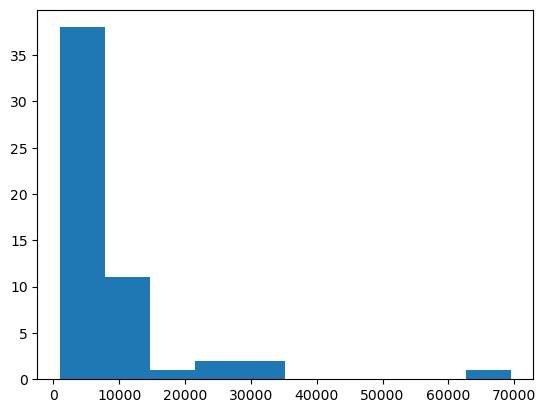

count    48.000000
mean     18.354167
std      12.660022
min       0.000000
25%      12.000000
50%      15.500000
75%      22.000000
max      75.000000
Name: age, dtype: float64


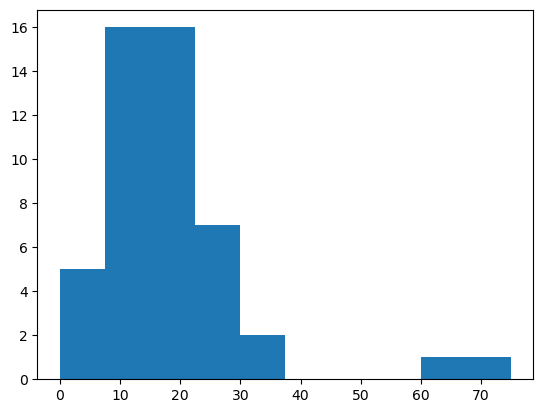

In [5]:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()
print(df['age'].describe())
df['age'].hist(grid=False)
plt.show()

In [6]:
# Price by brand:
df.loc[:,['price','brand']].groupby('brand').describe()

price                                                          \
           count          mean           std      min       25%      50%   
brand                                                                      
bmw          2.0   7500.000000   9192.388155   1000.0   4250.00   7500.0   
chevy        1.0   4000.000000           NaN   4000.0   4000.00   4000.0   
ford         9.0  15338.888889  20843.460872   1500.0   5500.00  11950.0   
gmc          1.0  26700.000000           NaN  26700.0  26700.00  26700.0   
honda        7.0   4814.285714   2607.315715   1200.0   3150.00   4800.0   
jeep         1.0   8500.000000           NaN   8500.0   8500.00   8500.0   
kia          1.0   1500.000000           NaN   1500.0   1500.00   1500.0   
lexus        2.0   1850.000000    919.238816   1200.0   1525.00   1850.0   
mazda        2.0  15870.000000  19968.695501   1750.0   8810.00  15870.0   
missing     16.0   6940.562500   7312.180596   1100.0   2487.50   5500.0   
subaru       1.0  11500.000000           NaN  11500.0  11500.00  11500.0   
tesla        1.0  23000.000000           NaN  23000.0  23000.00  23000.0   
toyota       8.0   6553.125000   4663.774481   2000.0   4356.25   5750.0   
volkswagen   1.0   2600.000000           NaN   2600.0   2600.00   2600.0   
volvo        2.0   7992.500000   5243.196782   4285.0   6138.75   7992.5   

                               
                 75%      max  
brand                          
bmw         10750.00  14000.0  
chevy        4000.00   4000.0  
ford        13500.00  69500.0  
gmc         26700.00  26700.0  
honda        6250.00   8900.0  
jeep         8500.00   8500.0  
kia          1500.00   1500.0  
lexus        2175.00   2500.0  
mazda       22930.00  29990.0  
missing      7524.75  32000.0  
subaru      11500.00  11500.0  
tesla       23000.00  23000.0  
toyota       7087.50  17000.0  
volkswagen   2600.00   2600.0  
volvo        9846.25  11700.0

In [7]:
# Age by brand:
df.loc[:,['age','brand']].groupby('brand').describe()

age                                                      
           count       mean        std   min    25%   50%    75%   max
brand                                                                 
bmw          2.0  19.500000  10.606602  12.0  15.75  19.5  23.25  27.0
chevy        1.0  22.000000        NaN  22.0  22.00  22.0  22.00  22.0
ford         9.0  23.222222  21.188309   6.0  13.00  14.0  25.00  75.0
gmc          0.0        NaN        NaN   NaN    NaN   NaN    NaN   NaN
honda        6.0  13.833333   3.430258  10.0  12.25  13.0  14.50  20.0
jeep         0.0        NaN        NaN   NaN    NaN   NaN    NaN   NaN
kia          1.0  14.000000        NaN  14.0  14.00  14.0  14.00  14.0
lexus        2.0  25.500000   2.121320  24.0  24.75  25.5  26.25  27.0
mazda        2.0   6.500000   9.192388   0.0   3.25   6.5   9.75  13.0
missing     13.0  21.307692  13.786374   4.0  15.00  18.0  23.00  62.0
subaru       1.0   6.000000        NaN   6.0   6.00   6.0   6.00   6.0
tesla        1.0   7.000000        NaN   7.0   7.00   7.0   7.00   7.0
toyota       7.0  15.857143   5.047394   8.0  13.00  17.0  18.50  23.0
volkswagen   1.0  19.000000        NaN  19.0  19.00  19.0  19.00  19.0
volvo        2.0  15.000000   5.656854  11.0  13.00  15.0  17.00  19.0

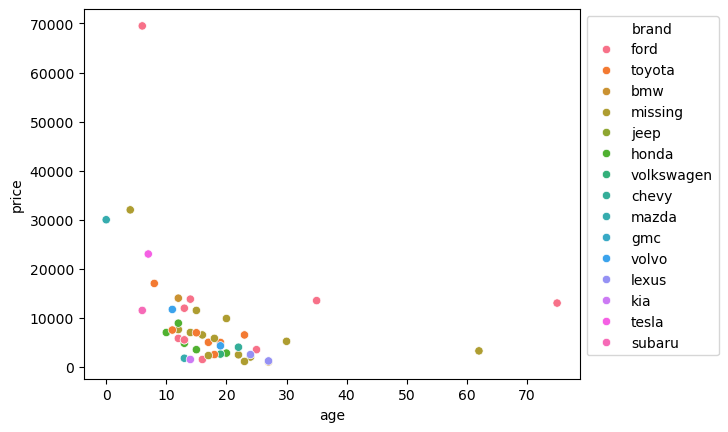

In [8]:
ax = sns.scatterplot(data=df, x='age', y='price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

c:\Users\oaakb\anaconda3\envs\DataScience\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


           log_price   log_age
log_price   0.872898 -0.241872
log_age    -0.241872  0.285100
           log_price   log_age
log_price   1.000000 -0.501888
log_age    -0.501888  1.000000


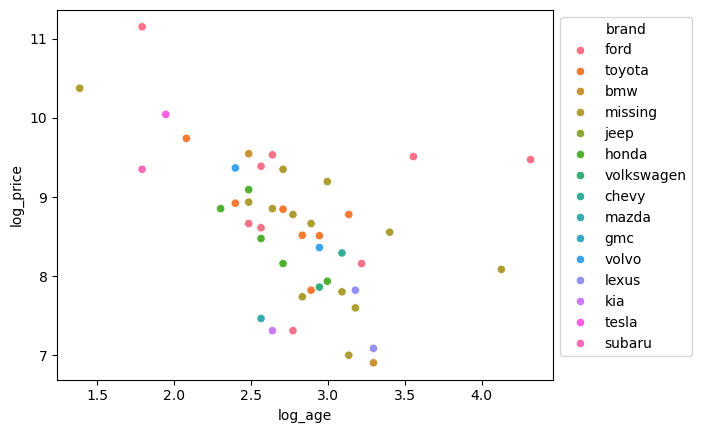

In [9]:
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

ax = sns.scatterplot(data=df, x='log_age', y='log_price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

print(df.loc[:,['log_price','log_age']].cov())
print(df.loc[:,['log_price','log_age']].corr())

## The Lab:


1. Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
2. Get your search results of interest using `requests` and extract data from them using `beautifulSoup`, using code similar to what's above.
3. Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

In [65]:
#I chose to look at different bikes

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from bs4 import BeautifulSoup as soup # HTML parser
import re # Regular expressions
import requests # Page requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://cnj.craigslist.org/search/bia#search=2~gallery~72'
raw = requests.get(url,headers=header) # Get page

print(raw)

#Target data; Year, Price, Type (electric, mountain, kids, etc...), Brand

bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

brands = [
  "trek",
  "zizzo",
  "schwinn",
  "jamis",
  "specialized",
  "giant",
  "cannondale",
  "scott",
  "cervelo",
  "santa cruz",
  "kona",
  "bianchi",
  "canyon",
  "orbea",
  "bmc",
  "pinarello",
  "colnago",
  "fuji",
  "felt",
  "wilier",
  "lapierre",
  "merida",
  "cube",
  "gt",
  "norco",
  "marin",
  "yeti",
  "transition",
  "rocky mountain",
  "surly",
  "all-city",
  "salsa",
  "raleigh"
]

types = [
    "road",
    "endurance roadike",
    "race road",
    "gravel",
    "cyclocross",
    "trial",
    "triathlon",
    "track",
    "fixed gear",
    "single speed",
    "touring",
    "bikepacking",
    "commuter",
    "city",
    "hybrid",
    "fitness",
    "cruiser",
    "comfort",
    "folding",
    "cargo",
    "electric",
    "mountain",
    "mountain",
    "fat",
    "bmx",
    "dirt",
    "kids",
    "tricycle",
    "handcycle"
]

data = [] # We'll save our listings in this object

for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get brand from the title string:
    words = title.split()
    hits = [word for word in words if word in brands] # Find brands in the title
    hits_type = [word for word in words if word in types] # Find types in the title

    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]

    if len(hits_type) == 0:
        bike_type = 'missing'
    else:
        bike_type = hits_type[0]

    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title ) # Find year references

    if regex_search is None: # If no hits, record year as missing value
        year = np.nan

    else: # If hits, record year as first match
        year = regex_search.group(0)

    data.append({'title':title,'price':price,'year':year,'link':link,'brand':brand, 'type':bike_type})

print(len(data))

<Response [200]>
307


In [66]:
# Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2026-df['year']
print(df.shape)
df.to_csv('./src/craigslist_cville_cars.csv') # Save data in case of a disaster
df.head()

print(df['type'].unique())


(307, 7)
['folding' 'kids' 'missing' 'electric' 'cruiser' 'road' 'mountain' 'bmx'
 'commuter' 'tricycle' 'gravel' 'touring' 'comfort' 'hybrid' 'fat']


In [67]:
df2 = df.copy() #make a copy of df to be safe

#standardize "missing"
for col in ["brand", "type"]:
    df2[col] = df2[col].fillna("missing").astype(str).str.lower()

#clean title
df2["title"] = df2["title"].fillna("").astype(str).str.lower()

#keep reasonable rows
df2 = df2[df2["price"].notna()]
df2 = df2[(df2["age"].isna()) | ((df2["age"] >= 0) & (df2["age"] <= 60))]

count     306.000000
mean      371.689542
std       655.855111
min         0.000000
25%        60.000000
50%       149.000000
75%       315.000000
max      4200.000000
Name: price, dtype: float64


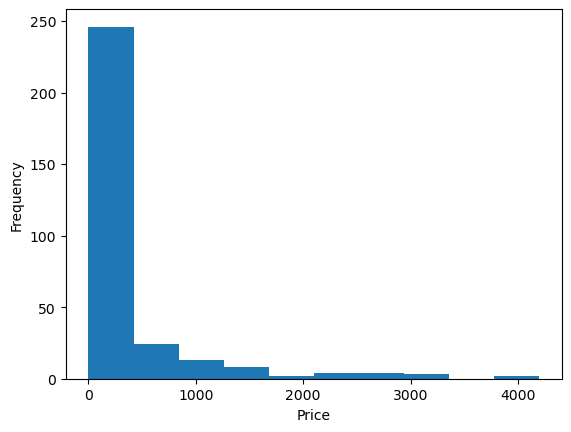

count    22.000000
mean     21.000000
std      17.007001
min       2.000000
25%       4.000000
50%      22.000000
75%      36.500000
max      47.000000
Name: age, dtype: float64


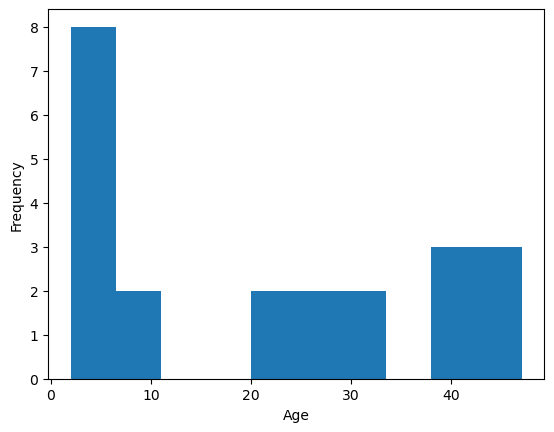

In [68]:
#Show frequency distrubtion of price
print(df2['price'].describe())
df2['price'].hist(grid=False)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#Show frequency distrubtion of age
print(df2['age'].describe())
df2['age'].hist(grid=False)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Response: 

Bike prices are strongle right-skewed. Most listings cluster at the low end, with a long tail of high-priced outlier reaching ~$4,000. Median price is a better summary than the mean. Additionally, given the strong right skew in price and the concentration of newer bikes, it's likely that a small number of newer/high-end listings drive the extreme prices.

In [69]:
# Price by brand:
df2.loc[:,['price','brand']].groupby('brand').describe()

price                                                             \
             count         mean          std    min      25%     50%      75%   
brand                                                                           
bianchi        2.0   242.000000   165.462987  125.0   183.50   242.0   300.50   
cannondale     7.0   514.285714   177.867661  275.0   400.00   550.0   575.00   
fuji           6.0   312.333333   353.449666   50.0    92.25   219.5   306.25   
giant         11.0   650.818182   872.679989   40.0    62.00   250.0   872.50   
gt             6.0   145.666667    93.811868    0.0   106.25   152.0   191.00   
jamis          1.0   160.000000          NaN  160.0   160.00   160.0   160.00   
missing      208.0   316.000000   588.111166    0.0    50.00   122.5   231.25   
pinarello      2.0  1650.000000  1202.081528  800.0  1225.00  1650.0  2075.00   
raleigh        7.0   242.857143    93.222724  100.0   187.50   225.0   325.00   
schwinn       30.0   538.633333   978.689922   35.0    77.50   149.5   193.50   
specialized    6.0   978.333333  1050.817142  170.0   375.00   475.0  1250.00   
trek          17.0   374.941176   692.276631   30.0   115.00   175.0   250.00   
zizzo          3.0   151.666667    67.144124   75.0   127.50   180.0   190.00   

                     
                max  
brand                
bianchi       359.0  
cannondale    825.0  
fuji         1000.0  
giant        2800.0  
gt            275.0  
jamis         160.0  
missing      4200.0  
pinarello    2500.0  
raleigh       350.0  
schwinn      3200.0  
specialized  2900.0  
trek         3000.0  
zizzo         200.0

Response: 

Prices vary a lot by brand, but he distribution is clearly skwered by outliers and small sample size. The media is more reliable than the mean for comparing brands. Higher-end brands like pinarello and specialized have much higher typical prices, while mass market brand like gt or zizzo cluster much lower. 

In [70]:
# Price by type:
df2.loc[:,['price','type']].groupby('type').describe()

price                                                             \
          count         mean         std     min      25%     50%      75%   
type                                                                         
bmx        24.0   129.333333   94.826004     0.0    63.75   100.0   200.00   
comfort     1.0   100.000000         NaN   100.0   100.00   100.0   100.00   
commuter    2.0   755.000000  841.457070   160.0   457.50   755.0  1052.50   
cruiser    26.0   127.923077   38.554816    60.0   101.50   125.0   161.25   
electric    5.0   529.000000  348.862437   145.0   350.00   350.0   900.00   
fat         1.0   149.000000         NaN   149.0   149.00   149.0   149.00   
folding     6.0   709.166667  975.758252    75.0   120.00   190.0   950.00   
gravel      2.0  1400.000000  141.421356  1300.0  1350.00  1400.0  1450.00   
hybrid      4.0   154.750000   66.610184   100.0   115.00   134.5   174.25   
kids       16.0    69.062500   83.490893    20.0    42.50    50.0    56.25   
missing   156.0   437.358974  785.978083     0.0    50.00   160.0   400.00   
mountain   38.0   501.473684  684.307728     0.0   113.75   179.5   562.50   
road       22.0   272.500000  328.105638     1.0    81.25   155.0   344.25   
touring     2.0   325.000000   70.710678   275.0   300.00   325.0   350.00   
tricycle    1.0   195.000000         NaN   195.0   195.00   195.0   195.00   

                  
             max  
type              
bmx        400.0  
comfort    100.0  
commuter  1350.0  
cruiser    209.0  
electric   900.0  
fat        149.0  
folding   2500.0  
gravel    1500.0  
hybrid     250.0  
kids       375.0  
missing   4200.0  
mountain  3000.0  
road      1400.0  
touring    375.0  
tricycle   195.0

Response:

Prices differ a lot by bike type. Higher performance catergoires like gravel and commuter/electric bikes tend to be more expensive. Kids, bmx, and cruiser listings cluster much lower. The "missing" type group is large and has huge spread, so it can skew averages.

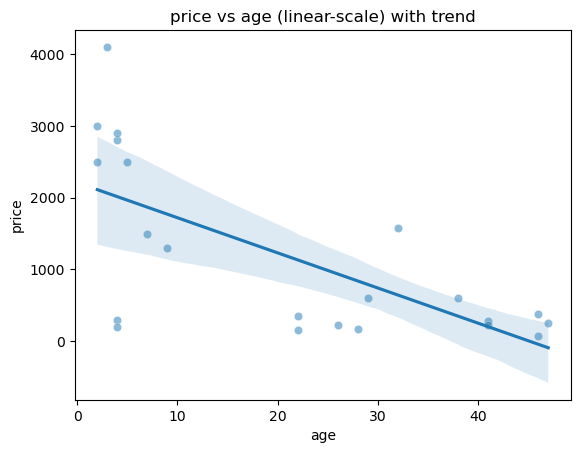

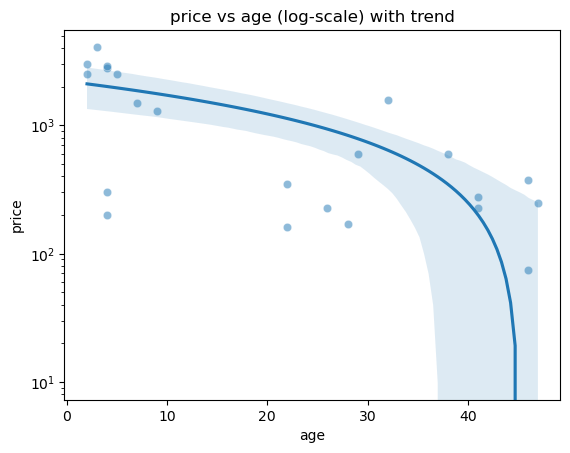

In [ ]:
#Plot a regression plot of price vs age with both linear and log scales

plt.figure()
sns.scatterplot(data=df2, x="age", y="price", alpha=0.5)
sns.regplot(data=df2, x="age", y="price", scatter=False)
plt.yscale("linear")
plt.title("price vs age (linear-scale) with trend")
plt.show()

plt.figure()
sns.scatterplot(data=df2, x="age", y="price", alpha=0.5)
sns.regplot(data=df2, x="age", y="price", scatter=False)
plt.yscale("log")
plt.title("price vs age (log-scale) with trend")
plt.show()

Response

The plot shows a clear negative relationship between age and price. Newer bikes cluster at higher prices, and as bikes get older the typical listing price drops (even on a log scale which is interesting). The curve and wide shaded band at high ages also suggest lots of variability and fewer data points for older bikes.

In [75]:
#Comparing median prices of missing year (false) vs has year (true)
print(df2.groupby(df2["year"].isna())["price"].median())

year
False    487.5
True     137.0
Name: price, dtype: float64


Response:

Listings with a detected year have a much higher media price than listings missing a year. This might be suggesting that sellers who include the year are often posting new/higher-quality bikes (or at least more "serious" listings). It also hints that "missing year" listings may be older/cheaper or less detailed, which can bias analyses that only use bikes with known years.

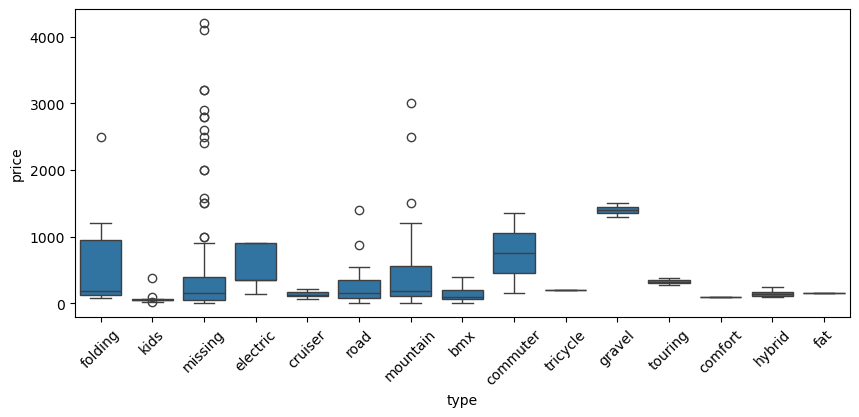

In [76]:
#Boxplot distribution of price by type

plt.figure(figsize=(10,4))
sns.boxplot(data=df2, x="type", y="price")
plt.xticks(rotation=45)
plt.show()

Response:

The boxplot shows that price varies a lot by bike type. You can also see a big spreads and many outliers for type like missing, which suggests Craigslist has a mix of normal listings plus a few very expensive bikes that can inflate average. 